In [20]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras.layers import Dense, Embedding, Input, Flatten, Concatenate, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.utils import shuffle

In [3]:
!wget -nc http://files.grouplens.org/datasets/movielens/ml-20m.zip

--2026-06-25 06:13:07--  http://files.grouplens.org/datasets/movielens/ml-20m.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://files.grouplens.org/datasets/movielens/ml-20m.zip [following]
--2026-06-25 06:13:07--  https://files.grouplens.org/datasets/movielens/ml-20m.zip
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 198702078 (189M) [application/zip]
Saving to: ‘ml-20m.zip’

ml-20m.zip          100%[===================>] 189.50M  54.6MB/s    in 3.8s    

2026-06-25 06:13:11 (50.4 MB/s) - ‘ml-20m.zip’ saved [198702078/198702078]



In [6]:
!unzip -n ml-20m.zip

Archive:  ml-20m.zip
   creating: ml-20m/
  inflating: ml-20m/genome-scores.csv  
  inflating: ml-20m/genome-tags.csv  
  inflating: ml-20m/links.csv        
  inflating: ml-20m/movies.csv       
  inflating: ml-20m/ratings.csv      
  inflating: ml-20m/README.txt       
  inflating: ml-20m/tags.csv         


In [9]:
df = pd.read_csv('/content/ml-20m/ratings.csv')

In [10]:
df

,userId,movieId,rating,timestamp
0,1,2,3.5,1112486027
1,1,29,3.5,1112484676
2,1,32,3.5,1112484819
3,1,47,3.5,1112484727
4,1,50,3.5,1112484580
...,...,...,...,...
20000258,138493,68954,4.5,1258126920
20000259,138493,69526,4.5,1259865108
20000260,138493,69644,3.0,1260209457
20000261,138493,70286,5.0,1258126944


In [11]:
df.userId = pd.Categorical(df.userId)
df['new_user_id'] = df.userId.cat.codes

In [13]:
df.movieId = pd.Categorical(df.movieId)
df['new_movie_id'] = df.movieId.cat.codes

In [14]:
userids = df['new_user_id'].values
movieids = df['new_movie_id'].values
ratings = df['rating'].values

In [29]:
userids, movieids, ratings = shuffle(userids, movieids, ratings)

Ntrain = int(len(userids)*0.8)
userids_train, movieids_train, ratings_train = userids[:Ntrain], movieids[:Ntrain], ratings[:Ntrain]
userids_test, movieids_test, ratings_test = userids[Ntrain:], movieids[Ntrain:], ratings[Ntrain:]

avg_rating = ratings_train.mean()
ratings_train -= avg_rating
ratings_test -= avg_rating

In [18]:
N = len(set(userids))
M = len(set(movieids))

K = 30

In [23]:
def create_model(N, M, K):
  u = Input(shape=(1,))
  m = Input(shape=(1,))

  u_emb = Embedding(N, K)(u)
  m_emb = Embedding(M, K)(m)

  u_emb = Flatten()(u_emb)
  m_emb = Flatten()(m_emb)

  x = Concatenate()([u_emb, m_emb])
  x = Dense(400, activation='relu')(x)
  x = Dropout(0.2)(x)
  x = Dense(100, activation='relu')(x)
  x = Dense(1)(x)

  return Model([u, m], x)

In [37]:
model = create_model(N, M, K)

In [38]:
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

In [39]:
r = model.fit([userids_train, movieids_train], ratings_train, epochs=6, batch_size=1024, validation_data=([userids_test, movieids_test], ratings_test))

Epoch 1/6
15626/15626 ━━━━━━━━━━━━━━━━━━━━ 71s 4ms/step - loss: 0.7268 - val_loss: 0.6847
Epoch 2/6
15626/15626 ━━━━━━━━━━━━━━━━━━━━ 66s 4ms/step - loss: 0.6541 - val_loss: 0.6482
Epoch 3/6
15626/15626 ━━━━━━━━━━━━━━━━━━━━ 67s 4ms/step - loss: 0.6127 - val_loss: 0.6332
Epoch 4/6
15626/15626 ━━━━━━━━━━━━━━━━━━━━ 68s 4ms/step - loss: 0.5818 - val_loss: 0.6233
Epoch 5/6
15626/15626 ━━━━━━━━━━━━━━━━━━━━ 65s 4ms/step - loss: 0.5556 - val_loss: 0.6190
Epoch 6/6
15626/15626 ━━━━━━━━━━━━━━━━━━━━ 67s 4ms/step - loss: 0.5354 - val_loss: 0.6170


In [34]:
import matplotlib.pyplot as plt


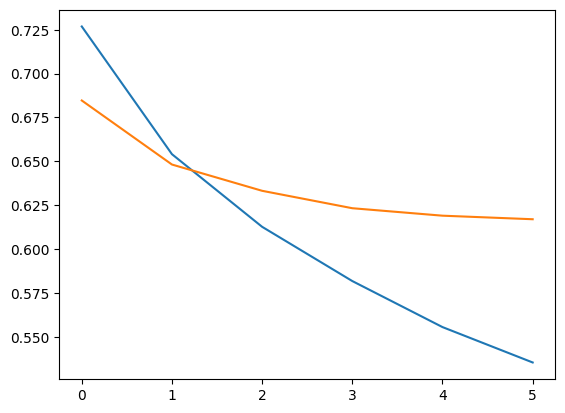

In [40]:
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
